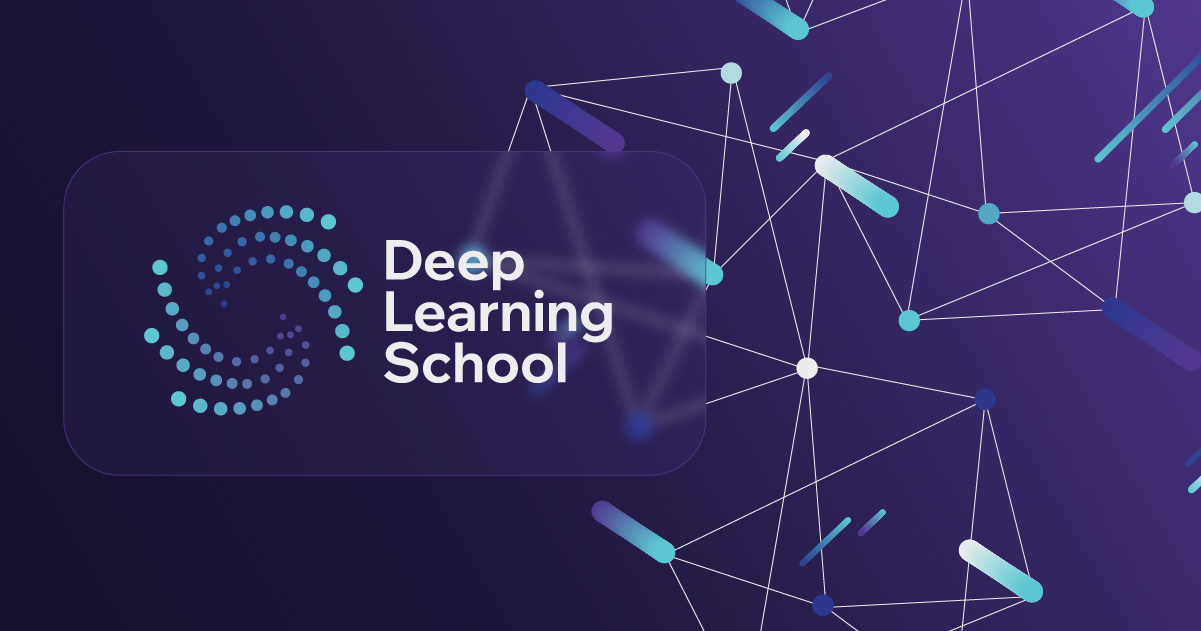

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Библиотека sklearn и классификация с помощью KNN</b></h1>

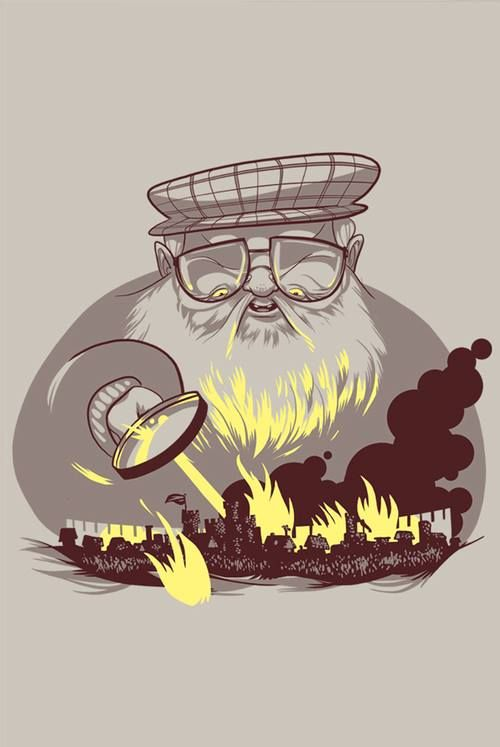

Датасет содержит данные о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Задача: предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

## Часть 1. Анализ и предобработка данных

Основные шаги:
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [372]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 54.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 46.3MB/s]


Импорт библиотек pandas, matplotlib, seaborn

In [373]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Загрузка датасета в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделаем значения колонки `S.No` наименованиями строк:

In [374]:
train_data = pd.read_csv("/content/game_of_thrones_train.csv", index_col='S.No')

Посмотрим, какие типы данных представлены в датасете

In [375]:
train_data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь посмотрим на столбцы с числовыми типами данных.


In [376]:
train_data.describe(include = [np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Предобработка (очистка) данных.

Пропуски в данных (missing values) уже закодированы как NaN. Проанализируем, в каких колонках и как часто встречаются NaN значения.

In [377]:
train_data.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


В некоторых колонках пропуски имеются практически у всех записей. В таком случае заполнить эти значения некоторой статистикой по данным будет некорректно, т.к. из-за нехватки данных расчеты статистик будут неверными. Поэтому колонки с большим количеством пропусков лучше удалить.

In [378]:
train_data.drop(columns=['mother', 'father', 'heir', 'isAliveMother', 'isAliveFather', 'isAliveHeir'], inplace=True)

In [379]:
train_data.head(10)

,name,title,male,culture,dateOfBirth,house,spouse,book1,book2,book3,book4,book5,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,House Frey,Perra Royce,1,1,1,1,1,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,House Swyft,NaN,0,0,0,1,0,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,House Arryn,Viserys I Targaryen,0,0,0,0,0,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,House Santagar,Eldon Estermont,0,0,0,1,0,1.0,1,1,29.0,0,0.043478,1
6,Tommen Baratheon,NaN,1,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,0,0,NaN,5,1.000000,1
7,Valarr Targaryen,Hand of the King,1,Valyrian,183.0,House Targaryen,Kiera of Tyrosh,0,0,0,0,0,1.0,1,1,26.0,0,0.431438,0
8,Viserys I Targaryen,NaN,1,NaN,NaN,NaN,NaN,0,0,0,0,0,NaN,0,0,NaN,5,0.678930,0
9,Wilbert,Ser,1,NaN,NaN,NaN,NaN,0,0,1,0,0,NaN,0,1,NaN,0,0.006689,0


Числовые признаки

У нас есть признак **popularity**. Построим гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

array([[<Axes: title={'center': 'popularity'}>]], dtype=object)

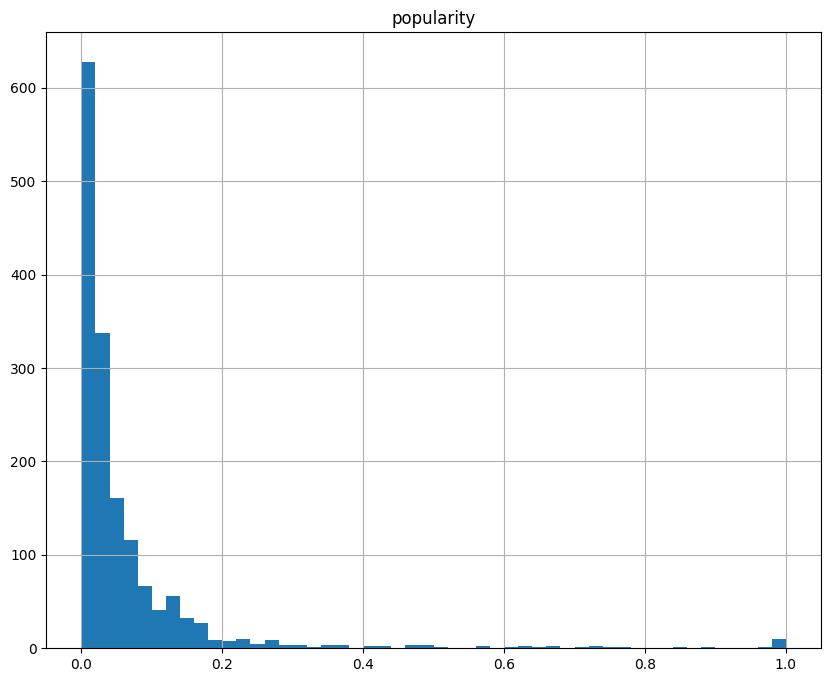

In [380]:
train_data.hist(column=["popularity"], figsize=(10, 8), bins=50, grid=True)

Для шкалирования признака **popularity** используем метод QuantileTransformer(), который преобразует исходное распределение к нормальному на основе информации о квантилях. После к полученному распределению применим метод MinMaxScaler, чтобы привести признак к масштабу [0, 1].

In [381]:
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

qt = QuantileTransformer(output_distribution='normal', random_state=42)
train_feature_trans = qt.fit_transform(train_data["popularity"].values.reshape(-1, 1))

scaler_pop = MinMaxScaler()
scaler_pop.fit(train_feature_trans)
train_feature_scaled = scaler_pop.transform(train_feature_trans)

Построим график распределения для преобразованного признака.

Text(0.5, 1.0, 'popularity')

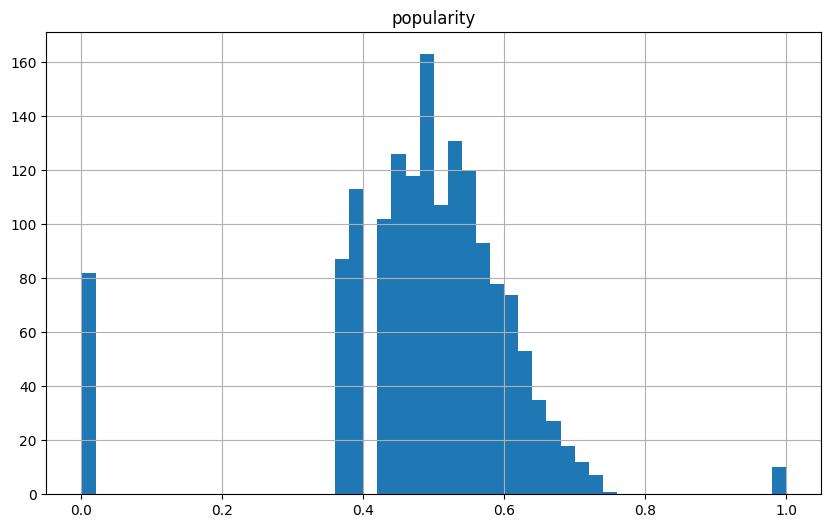

In [382]:
pd.DataFrame(train_feature_scaled).hist(figsize=(10, 6), bins=50, grid=True)

plt.title('popularity')

Заменяем старый столбец popularity на преобразованный.

In [383]:
train_data = train_data.drop(columns=["popularity"])
train_data['popularity_norm'] = train_feature_scaled

Теперь обработаем признак **numDeadRelations**.
Посмотрим на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations > 0`.

Создадим признак `boolDeadRelations`. Упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

array([[<Axes: title={'center': 'numDeadRelations'}>]], dtype=object)

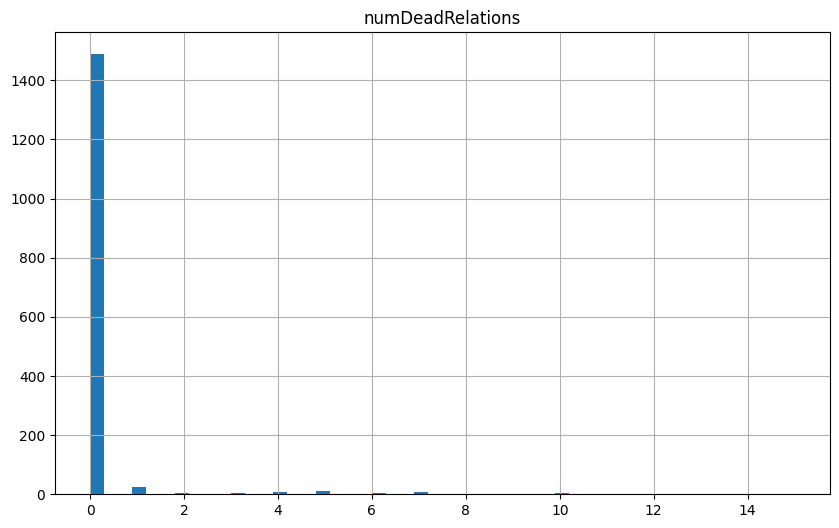

In [384]:
train_data.hist(column=["numDeadRelations"], figsize=(10, 6), bins=50, grid=True)

In [385]:
train_data.loc[train_data['numDeadRelations'] > 0, 'boolDeadRelations'] = 1
train_data.loc[train_data['numDeadRelations'] == 0, 'boolDeadRelations'] = 0

train_data = train_data.drop(columns=["numDeadRelations"])

Посмотрим на признак **age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, создадим два новых признака: `age_value` и `age_no_data`

- Там, где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там, где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.       

In [386]:
train_data['age_value'] = train_data['age']
train_data['age_value'] = train_data['age_value'].fillna(0)
train_data['age_no_data'] = [1 if np.isnan(x) else 0 for x in train_data['age']]

train_data = train_data.drop(columns=["age"])

Т.к. признаки `age` и `dateOfBirth` полностью совпадают, то не имеет смысла использовать оба признака для обучения модели. Поэтому удалим колонку `dateOfBirth` из тренировочного датасета.

In [387]:
train_data = train_data.drop(columns=["dateOfBirth"])

Категориальные признаки с большим количеством категорий

Признак **culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Посмотрим, какие значения принимает данный признак.

In [388]:
train_data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


In [389]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

Словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [ ]:
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
  for v in cultures_grouped[k]:
      cultures_grouped_inverted.update({v:k})

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [392]:
train_data['culture_grouped'] = train_data['culture'].str.lower().map(cultures_grouped_inverted)

train_data = train_data.drop(columns=["culture"])

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [393]:
train_data['culture_grouped'] = train_data['culture_grouped'].fillna('culture_no_data')

Категориальные признаки в линейных моделях

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах.

In [394]:
# Количество уникальнх значений в каждом столбце
train_data.nunique()

,0
name,1557
title,195
male,2
house,315
spouse,186
book1,2
book2,2
book3,2
book4,2
book5,2


In [ ]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
train_data.describe(include = [np.number]).T[['count', 'min', 'max']].assign(N_unique_values = train_data.nunique())

,count,min,max,N_unique_values
male,1557.0,0.0,1.0,2
book1,1557.0,0.0,1.0,2
book2,1557.0,0.0,1.0,2
book3,1557.0,0.0,1.0,2
book4,1557.0,0.0,1.0,2
book5,1557.0,0.0,1.0,2
isAliveSpouse,200.0,0.0,1.0,2
isMarried,1557.0,0.0,1.0,2
isNoble,1557.0,0.0,1.0,2
isAlive,1557.0,0.0,1.0,2


In [ ]:
pd.pivot_table(data = train_data, values = 'isAlive', index = 'isAliveSpouse', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


Анализ признаков.
  * Обработка категориальных признаков и перевод их в числа.
  * Анализ количественных признаков.

В датасете содержится категориальный признак `title`. Однако в датасете есть признак `isNoble`, обозначающий наличие титула. Таким образом, данные признаки дублируют друг друга и с высокой вероятностью между ними будет наблюдаться высокая корреляция, что нежелательно для модели. Поэтому для обучения оставим только признак `isNoble`.

In [397]:
train_data = train_data.drop(columns=["title"])

Рассмотрим признак `name`. В датафрейме все значения данного признака уникальны, поэтому посмотрим, сколько уникальных фамилий содержится в данном признаке.

In [398]:
train_data['name'].str.split(' ').str[-1].unique()

array(['Targaryen', 'Frey', 'Hill', 'Arryn', 'Santagar', 'Baratheon',
       'Wilbert', 'Osgrey', 'Will', '(orphan)', '(squire)', '(Standfast)',
       '(Treb)', 'Humble', 'Willam', 'Wylde', 'Willifer', 'Willit',
       'Wode', 'Fell', 'Heddle', 'Willum', 'Wolmer', 'Witch-eye', 'Woth',
       'Wulfe', 'Whittler', '(guard)', 'Waynwood', 'Wun', 'Wylla',
       'Manderly', 'Xhondo', 'Farwynd', 'Yna', 'Yorkel', 'Terys',
       'Yormwell', 'Henly', 'Ysilla', 'Zarabelo', 'Zei', 'Zekko', 'Loraq',
       'Wenda', 'Pyke', 'Timett', 'Velaryon', 'Tallhart', 'Tyrell',
       'Quence', 'Botley', 'Greyjoy', 'Blackwood', 'Mo', 'Quickfinger',
       'Quill', 'Quort', 'Qyle', 'Rafe', 'Ryndoon', 'Knight', 'Randa',
       'Rast', 'Rawney', 'Royce', 'Nayland', 'Oarsman', 'Lamb', 'Redtusk',
       'Rolfe', 'Redwyn', 'Webber', 'Reysen', 'Daemon)', 'III)',
       'Rhaegar)', 'Vance', 'Aemon)', 'Rowan', 'Farrow', 'Lonmouth',
       'Rigney', 'Rob', 'Reyne', 'Ashford', 'Flement)', 'Paege', 'Stark',
       'Rob

Сложно выделить крупные категории у данного признака - он содержит большое количество уникальных фамилий. Поэтому не будем использовать данный признак в обучении.

In [399]:
train_data = train_data.drop(columns=["name"])

Сопоставим признаки `spouse` и `isAliveSpouse`.

In [400]:
train_data.loc[train_data['spouse'].notna() & train_data['isAliveSpouse'].notna()]

,male,house,spouse,book1,book2,book3,book4,book5,isAliveSpouse,isMarried,isNoble,isAlive,popularity_norm,boolDeadRelations,age_value,age_no_data,culture_grouped
S.No,,,,,,,,,,,,,,,,,
2,1,House Frey,Perra Royce,1,1,1,1,1,1.0,1,1,1,0.735876,1.0,97.0,0,the Isles and Rivers
4,0,House Arryn,Viserys I Targaryen,0,0,0,0,0,0.0,1,1,0,0.651939,0.0,23.0,0,culture_no_data
5,0,House Santagar,Eldon Estermont,0,0,0,1,0,1.0,1,1,1,0.536834,0.0,29.0,0,Dorne
7,1,House Targaryen,Kiera of Tyrosh,0,0,0,0,0,1.0,1,1,0,0.694469,0.0,26.0,0,Old Nations
43,0,NaN,Yandry,0,0,0,0,1,1.0,1,0,1,0.531564,0.0,0.0,1,culture_no_data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,1,House Lannister of Casterly Rock,Amerei Frey,1,1,1,1,1,1.0,1,1,1,0.698640,1.0,23.0,0,culture_no_data
1540,0,House Stokeworth,Bronn,0,1,1,1,1,1.0,1,1,1,0.612936,1.0,40.0,0,culture_no_data
1545,1,House Hightower,Jorah Mormont,0,1,1,1,1,1.0,1,0,1,0.606462,1.0,0.0,1,culture_no_data


Видно, что для каждого не пустого значения `isAliveSpouse` определено имя супруга `spouse`. Получается, что признаки в каком-то смысле дублируют информацию - наличие (когда-либо) супруга. Поэтому не будем использовать с обучении признак `spouse`.

In [401]:
train_data = train_data.drop(columns=["spouse"])

train_data['isAliveSpouse'] = train_data['isAliveSpouse'].fillna(0)

Посмотрим, какие уникальные значения содержаться в колонке `house`

In [402]:
train_data['house'].value_counts().to_frame()

,count
house,
House Frey,89
Night's Watch,88
House Stark,56
House Targaryen,40
House Lannister,36
...,...
House Harlaw of Grey Garden,1
Summer Islands,1
House Condon,1


Выделим из наиболее "крупные" дома, остальные определим как 'another_house'.

In [403]:
train_data.loc[train_data['house'].notna(), 'house_group'] = 'another_house'

train_data.loc[train_data['house'] == 'House Frey', 'house_group'] = 'House Frey'
train_data.loc[train_data['house'] == "Night's Watch", 'house_group'] = "Night's Watch"
train_data.loc[train_data['house'] == "House Stark", 'house_group'] = "House Stark"
train_data.loc[train_data['house'] == "House Targaryen", 'house_group'] = "House Targaryen"
train_data.loc[train_data['house'] == "House Lannister", 'house_group'] = "House Lannister"
train_data.loc[train_data['house'] == "House Tyrell", 'house_group'] = "House Tyrell"
train_data.loc[train_data['house'] == "House Greyjoy", 'house_group'] = "House Greyjoy"

train_data['house_group'] = train_data['house_group'].fillna('house_no_data')

train_data = train_data.drop(columns=["house"])

Теперь, после группировки категориальных признаков, преобразуем их с помощью OneHotEncoder.

In [404]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

one_hot_encoded = encoder.fit_transform(train_data[['culture_grouped', 'house_group']])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['culture_grouped', 'house_group']), index=train_data.index)

In [405]:
train_data_encoded = pd.concat([train_data, one_hot_df], axis=1)

train_data_encoded = train_data_encoded.drop(['culture_grouped', 'house_group'], axis=1)

Проверим, коррелируют ли признаки между собой.

In [406]:
from google.colab.data_table import DataTable
DataTable.max_columns = 35

In [407]:
train_data_encoded.corr()

,male,book1,book2,book3,book4,book5,isAliveSpouse,isMarried,isNoble,isAlive,...,culture_grouped_the Stormlands,house_group_House Frey,house_group_House Greyjoy,house_group_House Lannister,house_group_House Stark,house_group_House Targaryen,house_group_House Tyrell,house_group_Night's Watch,house_group_another_house,house_group_house_no_data
male,1.000000,0.050526,0.024079,-0.008100,-0.101674,0.023022,-0.031835,-0.094385,0.133807,-0.148290,...,0.016425,-0.037072,0.031108,-0.028437,0.034450,-0.021758,-0.031734,0.067896,0.010280,-0.024689
book1,0.050526,1.000000,0.278116,0.145458,-0.009461,0.180542,0.031265,0.018072,0.041593,-0.112468,...,-0.020368,0.013232,-0.042737,0.123704,0.142005,0.005295,0.057044,0.078788,-0.072643,-0.077171
book2,0.024079,0.278116,1.000000,0.380968,0.102247,0.135720,0.141611,0.153332,-0.033216,-0.055998,...,0.072716,0.258476,0.091323,0.029212,0.210609,-0.061432,-0.017190,0.012892,-0.066688,-0.171249
book3,-0.008100,0.145458,0.380968,1.000000,0.329153,0.226547,0.149474,0.165407,0.007279,0.018427,...,0.058241,0.204366,-0.065541,0.003990,-0.091711,-0.084125,0.123855,0.179801,0.005175,-0.164202
book4,-0.101674,-0.009461,0.102247,0.329153,1.000000,0.302338,0.146237,0.141145,0.047394,0.284014,...,0.044747,0.144595,-0.017694,0.006424,-0.142585,-0.135068,0.075809,-0.030897,0.146778,-0.142624
book5,0.023022,0.180542,0.135720,0.226547,0.302338,1.000000,0.085217,0.065210,0.069338,0.032531,...,0.072294,-0.002241,-0.028849,0.019226,-0.047579,-0.019034,0.019970,0.106160,0.110910,-0.161310
isAliveSpouse,-0.031835,0.031265,0.141611,0.149474,0.146237,0.085217,1.000000,0.875376,0.126810,-0.020436,...,0.024963,0.109656,-0.031631,0.089824,0.037892,0.093314,0.083454,-0.082253,0.035805,-0.156652
isMarried,-0.094385,0.018072,0.153332,0.165407,0.141145,0.065210,0.875376,1.000000,0.132037,-0.049381,...,0.018436,0.112185,-0.039847,0.081432,0.018624,0.143918,0.076778,-0.093963,0.048876,-0.169402
isNoble,0.133807,0.041593,-0.033216,0.007279,0.047394,0.069338,0.126810,0.132037,1.000000,-0.060572,...,0.057335,-0.095312,-0.076999,-0.024239,-0.011128,0.101654,-0.013451,-0.155002,0.271381,-0.175719
isAlive,-0.148290,-0.112468,-0.055998,0.018427,0.284014,0.032531,-0.020436,-0.049381,-0.060572,1.000000,...,0.027077,0.071415,-0.060216,-0.031108,-0.004913,-0.187057,0.057036,-0.123900,0.065451,0.033892


Между некоторыми признаками 'домов' и 'культур' наблюдается заметная корреляция. Также коррелируют между собой признаки 'другая культура'/'нет данных о культуре' и 'другой дом'/'нет данных о доме'. Для того, чтобы признаки не дублировали друг друга, удалим признаки 'домов'.

In [499]:
train_data_encoded = train_data_encoded.drop([
    'house_group_House Frey', 'house_group_House Greyjoy',
    'house_group_House Lannister', 'house_group_House Stark',
    'house_group_House Targaryen', 'house_group_House Tyrell',
    "house_group_Night's Watch", 'house_group_another_house',
    'house_group_house_no_data'], axis=1)

### Анализ влияния признаков на целевую переменную.

Рассмотрим, влияет ли половая принадлежность на "выживаемость" персонажа.

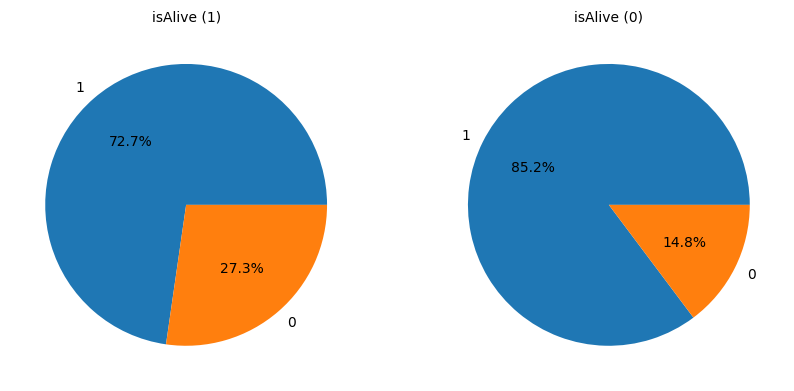

In [321]:
data_1 = train_data_encoded[train_data_encoded['male']== 1]['isAlive'].value_counts()
data_2 = train_data_encoded[train_data_encoded['male']== 0]['isAlive'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('isAlive (1)', fontsize=10)
ax2.set_title('isAlive (0)', fontsize=10)

plt.show()

Представители одного пола в книге умирают чуть чаще, чем другого. Но разница не такая большая (13.5%). Поэтому нельзя сказать, что автор однозначно "щадит" персонажей одного пола чаще, чем других.

Посмотрим, влияет ли на "выживаемость" персонажа его появление в книгах.

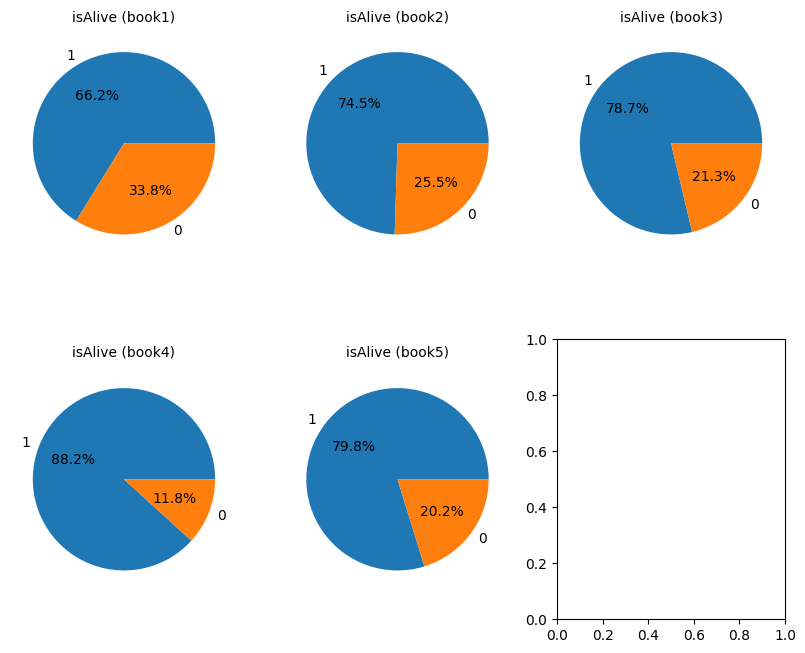

In [322]:
data_1 = train_data_encoded[train_data_encoded['book1']== 1]['isAlive'].value_counts()
data_2 = train_data_encoded[train_data_encoded['book2']== 1]['isAlive'].value_counts()
data_3 = train_data_encoded[train_data_encoded['book3']== 1]['isAlive'].value_counts()
data_4 = train_data_encoded[train_data_encoded['book4']== 1]['isAlive'].value_counts()
data_5 = train_data_encoded[train_data_encoded['book5']== 1]['isAlive'].value_counts()

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax3.pie(data_3.values, labels=data_3.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax4.pie(data_4.values, labels=data_4.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax5.pie(data_5.values, labels=data_5.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('isAlive (book1)', fontsize=10)
ax2.set_title('isAlive (book2)', fontsize=10)
ax3.set_title('isAlive (book3)', fontsize=10)
ax4.set_title('isAlive (book4)', fontsize=10)
ax5.set_title('isAlive (book5)', fontsize=10)

plt.show()

Можно заметить, что чаще всего умирали персонажи, появляющиеся в книге 1, реже всего персонажи умирали в книге 4, в остальных книгах у персонажей примерно одинаковые шансы умереть. Вероятно это связано с ходом сюжета в книгах.

Посмотрим, влияет ли на "выживаемость" персонажа его семейное положение и состояние супруга (жив супруг или нет).

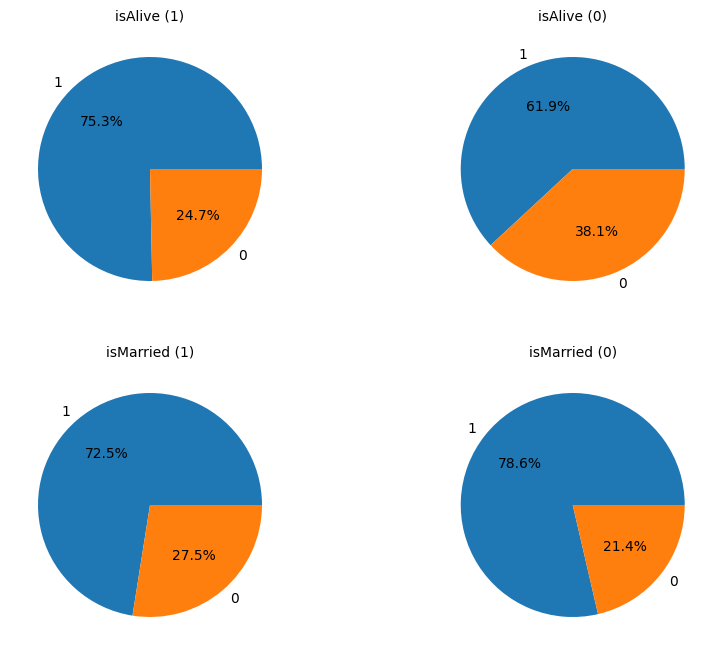

In [323]:
data_1 = train_data_encoded[(train_data_encoded['isAliveSpouse']== 1) & (train_data_encoded['isMarried']== 1)]['isAlive'].value_counts()
data_2 = train_data_encoded[(train_data_encoded['isAliveSpouse']== 0) & (train_data_encoded['isMarried']== 1)]['isAlive'].value_counts()
data_3 = train_data_encoded[train_data_encoded['isMarried']== 1]['isAlive'].value_counts()
data_4 = train_data_encoded[train_data_encoded['isMarried']== 0]['isAlive'].value_counts()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax3.pie(data_3.values, labels=data_3.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax4.pie(data_4.values, labels=data_4.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('isAlive (1)', fontsize=10)
ax2.set_title('isAlive (0)', fontsize=10)
ax3.set_title('isMarried (1)', fontsize=10)
ax4.set_title('isMarried (0)', fontsize=10)

plt.show()

Семейное положение персонажа не особо влияет на его шансы выжить. Но, если персонаж в браке, вероятность его смерти немного повышается с гибелью супруга.

Посмотрим, влияет ли на выживаемость персонажа наличие титула.

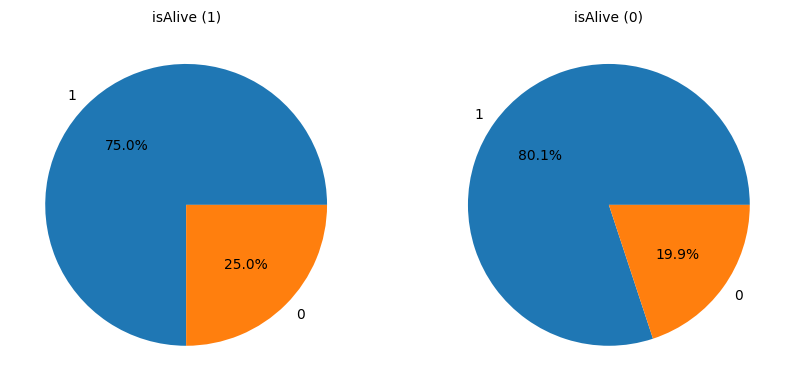

In [324]:
data_1 = train_data_encoded[train_data_encoded['isNoble']== 1]['isAlive'].value_counts()
data_2 = train_data_encoded[train_data_encoded['isNoble']== 0]['isAlive'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('isAlive (1)', fontsize=10)
ax2.set_title('isAlive (0)', fontsize=10)

plt.show()

Среди титулованных персонажей умирает чуть меньше персонажей (на 5%). Но в целом можно сказать, что знатные и незнатные персонажи умирают с одинаковой вероятностью.

Посмотрим, влияет ли популярность персонажа на его выживаемость.

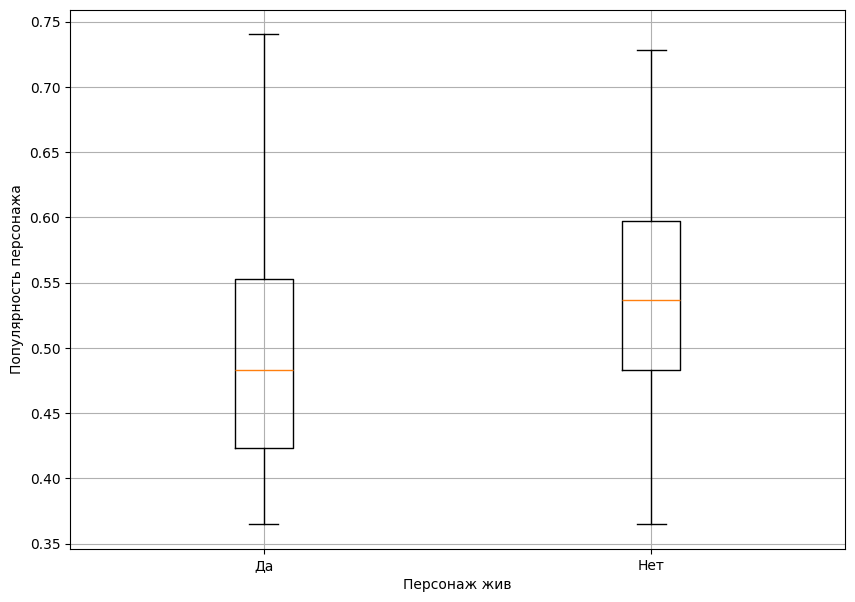

In [325]:
data1 = train_data_encoded['popularity_norm'][train_data_encoded['isAlive'] == 1]
data2 = train_data_encoded['popularity_norm'][train_data_encoded['isAlive'] == 0]

plt.figure(figsize=(10, 7))

plt.boxplot([data1, data2], showfliers=False)

plt.xlabel('Персонаж жив')
plt.ylabel('Популярность персонажа')
plt.xticks([1, 2], ['Да', 'Нет'])

plt.grid()

plt.show()

Видно, что медианная популярность погибших персонажей немного выше медианной популярности живых персонажей. Однако эта разница не настолько велика (около 5%), чтобы можно было сказать, что популярность перснажа заметно влияет на его популярность (автор не щадит персонажей даже в угоду читателям).  

Посмотрим, влияет ли возраст персонажа на его выживаемость.

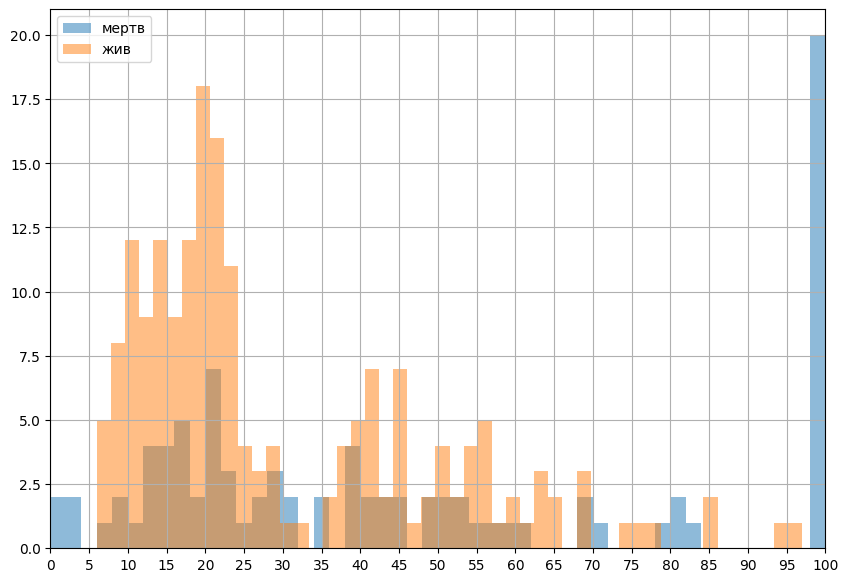

In [326]:
plt.figure(figsize=(10, 7))

plt.hist(train_data_encoded['age_value'][(train_data_encoded['age_no_data'] == 0) & (train_data_encoded['isAlive'] == 0)], alpha=0.5, label='мертв', bins= 50)
plt.hist(train_data_encoded['age_value'][(train_data_encoded['age_no_data'] == 0) & (train_data_encoded['isAlive'] == 1)], alpha=0.5, label='жив', bins=50)

plt.xticks(np.arange(0, 105, 5))
plt.xlim([0, 100])

plt.legend()
plt.grid()

plt.show()

Видно, что среди выживших значительную долю составляют молодые (до 25 лет). Среди мертвых персонажей больше всего наблдаются персонажи старшего возраста (старше 90 лет) - вероятно, что такие персонажи умерли не во время битв, а от естественных причин.  

Посмотрим, может ли влиять культурная принадлежность персонажа на его шансы выжить.

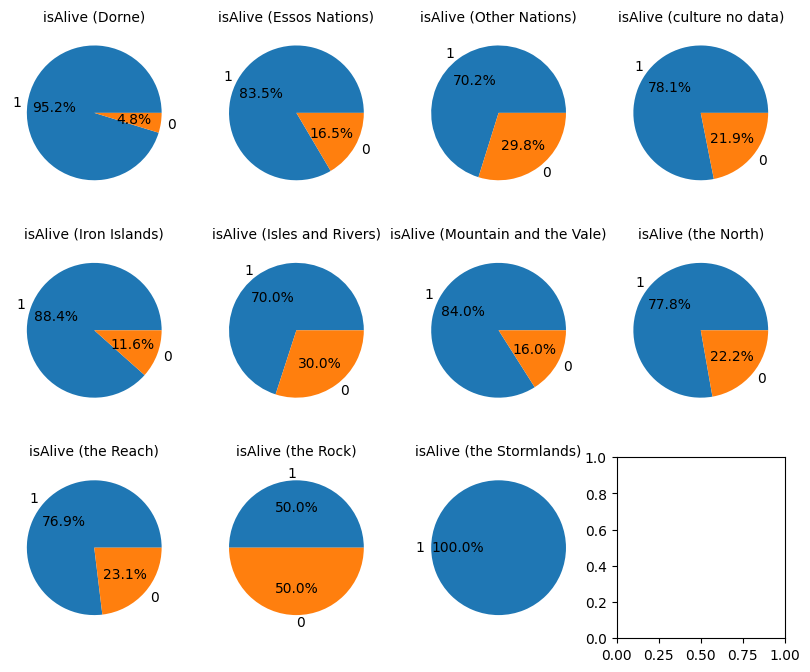

In [327]:
data_1 = train_data_encoded[train_data_encoded['culture_grouped_Dorne']== 1]['isAlive'].value_counts()
data_2 = train_data_encoded[train_data_encoded['culture_grouped_Essos Nations']== 1]['isAlive'].value_counts()
data_3 = train_data_encoded[train_data_encoded['culture_grouped_Other Nations']== 1]['isAlive'].value_counts()
data_4 = train_data_encoded[train_data_encoded['culture_grouped_culture_no_data']== 1]['isAlive'].value_counts()
data_5 = train_data_encoded[train_data_encoded['culture_grouped_the Iron Islands']== 1]['isAlive'].value_counts()
data_6 = train_data_encoded[train_data_encoded['culture_grouped_the Isles and Rivers']== 1]['isAlive'].value_counts()
data_7 = train_data_encoded[train_data_encoded['culture_grouped_the Mountain and the Vale']== 1]['isAlive'].value_counts()
data_8 = train_data_encoded[train_data_encoded['culture_grouped_the North']== 1]['isAlive'].value_counts()
data_9 = train_data_encoded[train_data_encoded['culture_grouped_the Reach']== 1]['isAlive'].value_counts()
data_10 = train_data_encoded[train_data_encoded['culture_grouped_the Rock']== 1]['isAlive'].value_counts()
data_11 = train_data_encoded[train_data_encoded['culture_grouped_the Stormlands']== 1]['isAlive'].value_counts()

fig, ((ax1, ax2, ax3, ax4), (ax5, ax6, ax7, ax8), (ax9, ax10, ax11, ax12)) = plt.subplots(3, 4, figsize=(10, 8))

ax1.pie(data_1.values, labels=data_1.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax2.pie(data_2.values, labels=data_2.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax3.pie(data_3.values, labels=data_3.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax4.pie(data_4.values, labels=data_4.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax5.pie(data_5.values, labels=data_5.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax6.pie(data_6.values, labels=data_6.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax7.pie(data_7.values, labels=data_7.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax8.pie(data_8.values, labels=data_8.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax9.pie(data_9.values, labels=data_9.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax10.pie(data_10.values, labels=data_10.index, autopct='%1.1f%%', textprops={'fontsize': 10})
ax11.pie(data_11.values, labels=data_11.index, autopct='%1.1f%%', textprops={'fontsize': 10})

ax1.set_title('isAlive (Dorne)', fontsize=10)
ax2.set_title('isAlive (Essos Nations)', fontsize=10)
ax3.set_title('isAlive (Other Nations)', fontsize=10)
ax4.set_title('isAlive (culture no data)', fontsize=10)
ax5.set_title('isAlive (Iron Islands)', fontsize=10)
ax6.set_title('isAlive (Isles and Rivers)', fontsize=10)
ax7.set_title('isAlive (Mountain and the Vale)', fontsize=10)
ax8.set_title('isAlive (the North)', fontsize=10)
ax9.set_title('isAlive (the Reach)', fontsize=10)
ax10.set_title('isAlive (the Rock)', fontsize=10)
ax11.set_title('isAlive (the Stormlands)', fontsize=10)

plt.show()

Среди культурных групп можно выделить группы и большей или меньшей выживаемостью. То есть культурная принадлежность персонажа может влиять на его шанс выжить.

Создадим переменную `X`, которая будет хранить только значения признаков, которые были отобраны для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [526]:
X = train_data_encoded.drop(['isAlive'], axis=1)
y = train_data_encoded['isAlive']

In [527]:
scaler_age = MinMaxScaler()
scaler_age.fit(X[['age_value']])
age_scaled = scaler_age.transform(X[['age_value']])

In [528]:
X = X.drop(columns=["age_value"])
X['age_scaled'] = age_scaled

### Разделение датасета на обучащую и валидационные части (train и val)

In [529]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X.values, y.values, shuffle=True, test_size=0.2, random_state=44)

## Часть 2. Обучение моделей

In [429]:
from sklearn.linear_model import LogisticRegression

### Обучение моделм и получение предсказаний на тестовой выборке

Обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [481]:
# Шаг 1. создание модели
model = LogisticRegression()

# Шаг 2. обучение модели
model.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = model.predict(X_val)

In [482]:
model.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

## Часть 3. Оценка качества моделей

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [546]:
from sklearn.metrics import accuracy_score

Посчитаем метрику accuracy для модели `LogisticRegression`

In [547]:
# Шаг 3. Предсказание на тестовых данных

y_pred = model.predict(X_val)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8013


In [548]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8013


In [549]:
from sklearn.model_selection import GridSearchCV

model = RandomForestClassifier(random_state=42)

param_grid = {
    'max_depth': np.arange(1, 15),
    'min_samples_leaf': [1,2, 3, 4, 5],
    'criterion': ['gini', 'entropy']
}

gridsearch = GridSearchCV(model, param_grid, refit=True, scoring='accuracy', cv=4, n_jobs=-1)

gridsearch.fit(X_train, y_train)

print(gridsearch.best_params_)

{'criterion': 'gini', 'max_depth': np.int64(12), 'min_samples_leaf': 2}


In [550]:
best_model = gridsearch.best_estimator_

y_pred = best_model.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.8397


### Тестовый датасет

Загрузим тестовый датасет в Pandas DataFrame при помощи функции read_csv

In [551]:
test_data = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')

Посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [552]:
test_data.describe(include = 'object').T

,count,unique,top,freq
name,389,389,Tytos Lannister,1
title,221,109,Ser,78
culture,189,48,Northmen,30
mother,3,3,Dyanna Dayne,1
father,4,4,Maekar I Targaryen,1
heir,2,2,Duncan Targaryen,1
house,343,137,House Targaryen,22
spouse,76,75,Tyrion Lannister,2


In [553]:
test_data.describe(include = [np.number]).T[['count', 'min', 'max']]

,count,min,max
male,389.0,0.0,1.0
dateOfBirth,154.0,-28.0,298299.0
book1,389.0,0.0,1.0
book2,389.0,0.0,1.0
book3,389.0,0.0,1.0
book4,389.0,0.0,1.0
book5,389.0,0.0,1.0
isAliveMother,3.0,1.0,1.0
isAliveFather,4.0,0.0,0.0
isAliveHeir,2.0,0.0,1.0


In [ ]:
test_data.loc[test_data['age']<0] # Находим данные с ошибками в дате рождения и возрасте

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1685,Doreah,NaN,0,Lysene,278279.0,NaN,NaN,NaN,House Targaryen,NaN,...,1,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368
1869,Rhaego,NaN,0,NaN,298299.0,NaN,NaN,NaN,House Targaryen,NaN,...,0,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224


In [ ]:
#Аккуратно поправим тестовые данные, воспользовавшись следующим кодом:
test_data.loc[1685, 'dateOfBirth'] = 278
test_data.loc[1685, 'age'] = np.nan
test_data.loc[1689, 'dateOfBirth'] = 299
test_data.loc[1689, 'age'] = np.nan

Преобразуем признаки в тестовом датасете по тому же пайплайну, как мы преобразовывали обучающие данные. Применим лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [556]:
test_data.drop(columns=['mother', 'father', 'heir', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'dateOfBirth', 'title', 'name', 'spouse', 'house'], inplace=True)

# Преобоазование признака popularity
test_feature_trans = qt.fit_transform(test_data["popularity"].values.reshape(-1, 1))

test_feature_scaled = scaler_pop.transform(test_feature_trans)
test_data = test_data.drop(columns=["popularity"])
test_data['popularity_norm'] = test_feature_scaled

# Преобразование признака numDeadRelations
test_data.loc[test_data['numDeadRelations'] > 0, 'boolDeadRelations'] = 1
test_data.loc[test_data['numDeadRelations'] == 0, 'boolDeadRelations'] = 0
test_data = test_data.drop(columns=["numDeadRelations"])

# Преобразование признака age
test_data['age_value'] = test_data['age']
test_data['age_value'] = test_data['age_value'].fillna(0)
test_data['age_no_data'] = [1 if np.isnan(x) else 0 for x in test_data['age']]
test_data = test_data.drop(columns=["age"])

age_scaled = scaler_age.transform(test_data[['age_value']])
test_data = test_data.drop(columns=["age_value"])
test_data['age_scaled'] = age_scaled

# Преобразование признака culture
test_data['culture_grouped'] = test_data['culture'].str.lower().map(cultures_grouped_inverted)
test_data = test_data.drop(columns=["culture"])
test_data['culture_grouped'] = test_data['culture_grouped'].fillna('culture_no_data')

# Преобразование признака isAliveSpouse
test_data['isAliveSpouse'] = test_data['isAliveSpouse'].fillna(0)

# Преобразование категориальных признаков
one_hot_encoded = encoder.fit_transform(test_data[['culture_grouped']])

one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(['culture_grouped']), index=test_data.index)

test_data_encoded = pd.concat([test_data, one_hot_df], axis=1)

test_data_encoded = test_data_encoded.drop(['culture_grouped'], axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (389). n_quantiles is set to n_samples.
  warnings.warn(


### Файл `submission.csv`

In [557]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.8MB/s]


In [558]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [559]:
y_pred = best_model.predict(test_data_encoded)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [560]:
submission['isAlive'] = y_pred

Сохраним измененный Pandas DataFrame в csv файл:

In [544]:
submission.to_csv("/content/new_submission.csv", index=False)